In [48]:
# pandas ライブラリをインポートする (使える状態にする)
import pandas as pd

# NH.xlsx という Excel ファイルの「data2」というワークシートを読み込み，
# dataframe という形式で変数 df0 に代入する
df0 = pd.read_excel('NH.xlsx', sheet_name='data2', index_col="#")

# 変数 df0 の内容の表示
display(df0)
# 変数の内容は，上のツールバーの「変数」からも確認できる

,最寄駅,駅まで,価格,部屋数,間取り,面積,建築年,構造,都市計画,取引年,改装
#,,,,,,,,,,,
0,夙川,2.0,4200,3.0,２ＬＤＫ,55,1998.0,ＲＣ,２中住専,2022,0.0
1,夙川,3.0,5800,5.0,４ＬＤＫ,85,1998.0,ＲＣ,２中住専,2021,0.0
2,夙川,3.0,6000,5.0,４ＬＤＫ,90,1998.0,ＲＣ,２中住専,2020,0.0
3,夙川,3.0,5400,4.0,３ＬＤＫ,70,1998.0,ＲＣ,２中住専,2020,1.0
4,夙川,2.0,8800,4.0,３ＬＤＫ,90,2013.0,ＲＣ,２中住専,2020,NaN
...,...,...,...,...,...,...,...,...,...,...,...
6427,夙川,8.0,4000,4.0,３ＬＤＫ,75,1997.0,ＲＣ,１中住専,2008,0.0
6428,夙川,7.0,2600,4.0,３ＬＤＫ,70,1997.0,ＲＣ,１中住専,2007,0.0
6429,門戸厄神,11.0,2600,4.0,３ＬＤＫ,70,2000.0,ＲＣ,１中住専,2008,0.0


In [49]:
# 築年数列を追加
df1 = df0.assign(築年数=df0['取引年'] - df0['建築年'])
display(df1)

,最寄駅,駅まで,価格,部屋数,間取り,面積,建築年,構造,都市計画,取引年,改装,築年数
#,,,,,,,,,,,,
0,夙川,2.0,4200,3.0,２ＬＤＫ,55,1998.0,ＲＣ,２中住専,2022,0.0,24.0
1,夙川,3.0,5800,5.0,４ＬＤＫ,85,1998.0,ＲＣ,２中住専,2021,0.0,23.0
2,夙川,3.0,6000,5.0,４ＬＤＫ,90,1998.0,ＲＣ,２中住専,2020,0.0,22.0
3,夙川,3.0,5400,4.0,３ＬＤＫ,70,1998.0,ＲＣ,２中住専,2020,1.0,22.0
4,夙川,2.0,8800,4.0,３ＬＤＫ,90,2013.0,ＲＣ,２中住専,2020,NaN,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6427,夙川,8.0,4000,4.0,３ＬＤＫ,75,1997.0,ＲＣ,１中住専,2008,0.0,11.0
6428,夙川,7.0,2600,4.0,３ＬＤＫ,70,1997.0,ＲＣ,１中住専,2007,0.0,10.0
6429,門戸厄神,11.0,2600,4.0,３ＬＤＫ,70,2000.0,ＲＣ,１中住専,2008,0.0,8.0


In [50]:
# 建築年 を 築年数 で置き換えて，価格 を右端に移動
df2 = df1[['最寄駅','駅まで','部屋数','間取り','面積','築年数','構造','都市計画','取引年','改装','価格']]
df2.columns=['sta.','to_sta.','rooms','fl.plan','area','age','bldg.struct.','luz','tx.yr.','reno','price']
df2.describe(include='all')

,sta.,to_sta.,rooms,fl.plan,area,age,bldg.struct.,luz,tx.yr.,reno,price
count,6390,6384.000000,5887.000000,5887,6392.000000,6288.000000,6329,6371,6392.000000,5642.000000,6392.000000
unique,34,NaN,NaN,19,NaN,NaN,5,11,NaN,NaN,NaN
top,西宮(阪神),NaN,NaN,３ＬＤＫ,NaN,NaN,ＲＣ,１中住専,NaN,NaN,NaN
freq,722,NaN,NaN,3783,NaN,NaN,4997,2877,NaN,NaN,NaN
mean,NaN,10.569549,3.888228,NaN,71.883605,19.256679,NaN,NaN,2015.697747,0.282347,2777.714643
std,NaN,6.575120,0.707041,NaN,17.109967,11.792488,NaN,NaN,4.818828,0.450181,1373.479506
min,NaN,0.000000,2.000000,NaN,15.000000,0.000000,NaN,NaN,2007.000000,0.000000,50.000000
25%,NaN,6.000000,4.000000,NaN,65.000000,10.000000,NaN,NaN,2012.000000,0.000000,1800.000000
50%,NaN,9.000000,4.000000,NaN,70.000000,17.000000,NaN,NaN,2016.000000,0.000000,2700.000000
75%,NaN,14.000000,4.000000,NaN,80.000000,25.000000,NaN,NaN,2020.000000,1.000000,3600.000000


In [51]:
df = df2.dropna()
x = df.drop('price', axis=1)
y = df['price']
df.describe(include='all')

,sta.,to_sta.,rooms,fl.plan,area,age,bldg.struct.,luz,tx.yr.,reno,price
count,5464,5464.000000,5464.000000,5464,5464.000000,5464.000000,5464,5464,5464.000000,5464.000000,5464.000000
unique,34,NaN,NaN,19,NaN,NaN,5,11,NaN,NaN,NaN
top,西宮(阪神),NaN,NaN,３ＬＤＫ,NaN,NaN,ＲＣ,１中住専,NaN,NaN,NaN
freq,616,NaN,NaN,3511,NaN,NaN,4332,2473,NaN,NaN,NaN
mean,NaN,10.518302,3.894766,NaN,72.221816,18.782211,NaN,NaN,2015.178075,0.281296,2789.257321
std,NaN,6.519745,0.702561,NaN,16.918077,11.760942,NaN,NaN,4.799241,0.449673,1370.224893
min,NaN,0.000000,2.000000,NaN,15.000000,0.000000,NaN,NaN,2007.000000,0.000000,50.000000
25%,NaN,6.000000,4.000000,NaN,65.000000,10.000000,NaN,NaN,2011.000000,0.000000,1800.000000
50%,NaN,9.000000,4.000000,NaN,70.000000,16.000000,NaN,NaN,2015.000000,0.000000,2700.000000
75%,NaN,14.000000,4.000000,NaN,80.000000,25.000000,NaN,NaN,2019.000000,1.000000,3600.000000


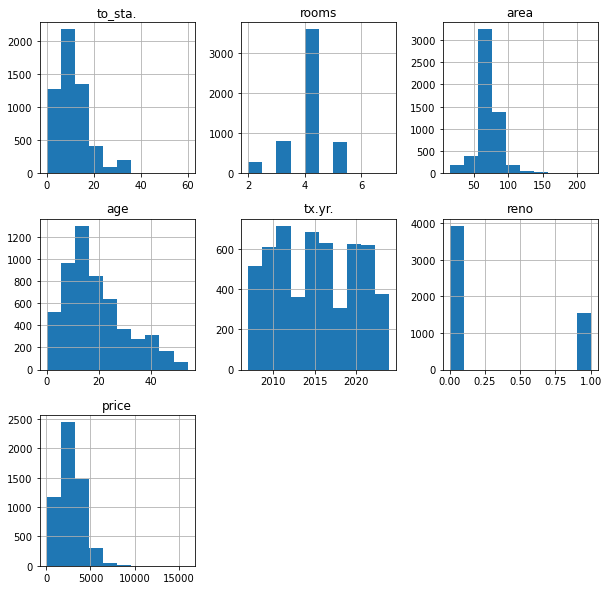

In [52]:
# 各変数のヒストグラム
import matplotlib.pyplot as plt

# figsize でグラフの大きさを大きくしている
df.hist(figsize=(10, 10))
plt.show()

,to_sta.,rooms,area,age,tx.yr.,reno,price
to_sta.,1.000000,0.151539,0.113583,0.006443,-0.011456,0.051346,-0.209028
rooms,0.151539,1.000000,0.633769,-0.120365,-0.038687,-0.027380,0.260501
area,0.113583,0.633769,1.000000,-0.133172,-0.003476,-0.014074,0.502882
age,0.006443,-0.120365,-0.133172,1.000000,0.277813,0.257056,-0.499426
tx.yr.,-0.011456,-0.038687,-0.003476,0.277813,1.000000,0.091886,0.247680
reno,0.051346,-0.027380,-0.014074,0.257056,0.091886,1.000000,-0.055136
price,-0.209028,0.260501,0.502882,-0.499426,0.247680,-0.055136,1.000000


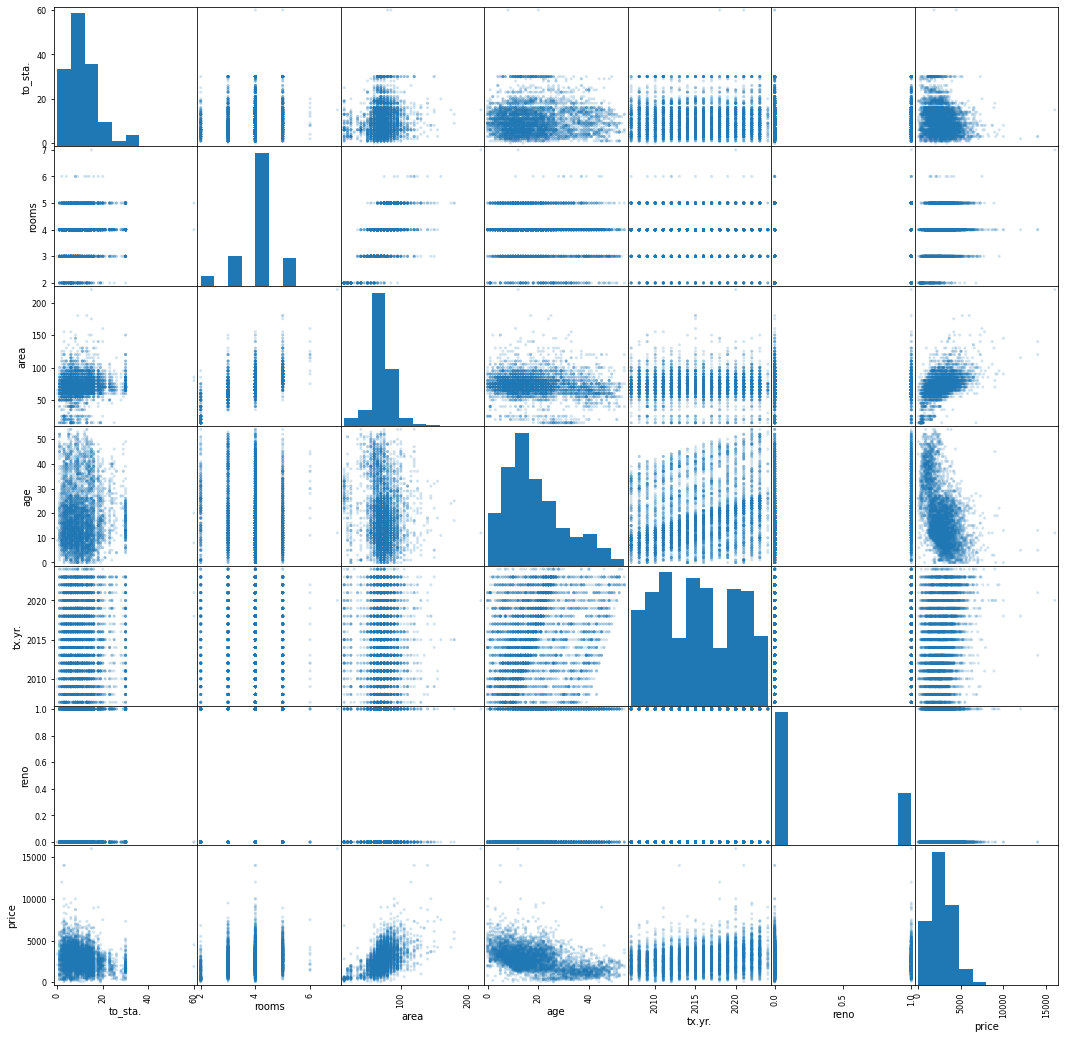

In [53]:
# 相関係数と散布図行列

# 相関係数表の表示 — 相関係数が1に近いほど強い正の相関，-1に近いほど強い負の相関，0に近いほど無相関
display(df.corr())

# 散布図行列の表示
from pandas.plotting import scatter_matrix
# figsize でグラフを大きくし，alpha でドットの透明度を上げている
sm = scatter_matrix(df, figsize=(18, 18), alpha=0.2)

In [54]:
# 学習データとテストデータの分割
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

print(len(x_train), len(x_test))

4098 1366


切片 =  -88.721336009678


,変数名,係数
0,area,39.804744


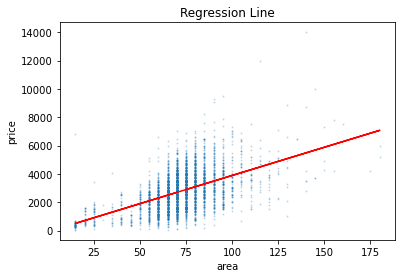

In [56]:
# 単回帰分析とその結果

# 説明変数を area のみに限定
x_train1 = x_train[["area"]]
x_test1 = x_test[["area"]]

# LinearRegression (回帰分析) モデルを生成して訓練データを適用
from sklearn.linear_model import LinearRegression
sr_model = LinearRegression()
sr_model.fit(x_train1, y_train)

# 結果の表示
print("切片 = ", sr_model.intercept_)
display(pd.DataFrame({"変数名": x_train1.columns, "係数": sr_model.coef_}))

# グラフによる可視化
import matplotlib.pyplot as plt

plt.title("Regression Line")    # タイトル
plt.xlabel("area")              # 横軸ラベル
plt.ylabel("price")             # 縦軸ラベル

plt.scatter(x_train1, y_train, s=1, alpha=0.2)                       # 散布図(青)
plt.plot(x_train1['area'], sr_model.predict(x_train1), color="red")  # 回帰直線(赤)

plt.show()  # 表示

In [57]:
# 決定係数の表示
# 0 ～ 1 で，1に近いほど良い成績
print("r^2 (訓練データ):   ", sr_model.score(x_train1, y_train))
print("r^2 (テストデータ): ", sr_model.score(x_test1, y_test))

# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
sr_pred_train = sr_model.predict(x_train1)
sr_pred_test = sr_model.predict(x_test1)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, sr_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, sr_pred_test)))

r^2 (訓練データ):    0.24626938866166315
r^2 (テストデータ):  0.2707466592408616
RMSE (訓練データ):    1177.8459880531923
RMSE (テストデータ):  1203.689576012131


切片 =  3896.20813663394


,変数名,係数
0,age,-58.767405


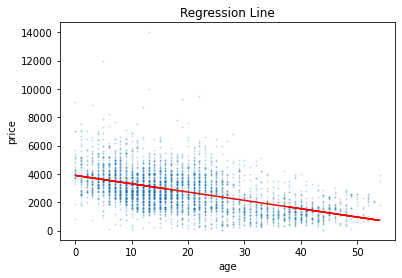

r^2 (訓練データ):    0.25793535805016954
r^2 (テストデータ):  0.22563057512809204
RMSE (訓練データ):    1168.69530545401
RMSE (テストデータ):  1240.3646611012903


In [59]:
# age でも単回帰分析をしてみる

# 説明変数を age のみに限定
x_train1 = x_train[["age"]]
x_test1 = x_test[["age"]]

# LinearRegression (回帰分析) モデルを生成して訓練データを適用
from sklearn.linear_model import LinearRegression
sr_model = LinearRegression()
sr_model.fit(x_train1, y_train)

# 結果の表示
print("切片 = ", sr_model.intercept_)
display(pd.DataFrame({"変数名": x_train1.columns, "係数": sr_model.coef_}))

# グラフによる可視化
import matplotlib.pyplot as plt

plt.title("Regression Line")    # タイトル
plt.xlabel("age")              # 横軸ラベル
plt.ylabel("price")             # 縦軸ラベル

plt.scatter(x_train1, y_train, s=1, alpha=0.2)                       # 散布図(青)
plt.plot(x_train1['age'], sr_model.predict(x_train1), color="red")  # 回帰直線(赤)

plt.show()  # 表示

# 決定係数の表示
# 0 ～ 1 で，1に近いほど良い成績
print("r^2 (訓練データ):   ", sr_model.score(x_train1, y_train))
print("r^2 (テストデータ): ", sr_model.score(x_test1, y_test))

# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
sr_pred_train = sr_model.predict(x_train1)
sr_pred_test = sr_model.predict(x_test1)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, sr_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, sr_pred_test)))

In [64]:
# 重回帰分析とその結果

# 説明変数として to_sta., rooms, area, age	tx.yr. を使用
x_train1 = x_train[['to_sta.','rooms','area','age','tx.yr.']]
x_test1 = x_test[['to_sta.','rooms','area','age','tx.yr.']]

# LinearRegression (回帰分析) モデルを生成して訓練データを適用
from sklearn.linear_model import LinearRegression
mr_model = LinearRegression()
mr_model.fit(x_train1, y_train)

# 結果の表示
print("切片 = ", mr_model.intercept_)
display(pd.DataFrame({"変数名": x_train1.columns, "係数": mr_model.coef_}))

# 決定係数の表示
print("r^2 (訓練データ):   ", mr_model.score(x_train1, y_train))
print("r^2 (テストデータ): ", mr_model.score(x_test1, y_test))

# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
mr_pred_train = mr_model.predict(x_train1)
mr_pred_test = mr_model.predict(x_test1)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, mr_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, mr_pred_test)))

切片 =  -224863.2413274006


,変数名,係数
0,to_sta.,-51.617361
1,rooms,-131.164218
2,area,39.984234
3,age,-64.537434
4,tx.yr.,112.659660


r^2 (訓練データ):    0.666892407407326
r^2 (テストデータ):  0.6383512597376523
RMSE (訓練データ):    783.0197133924742
RMSE (テストデータ):  847.6542897366058


In [65]:
# FNNの学習を行う
from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(random_state=0, max_iter=400)
mlp_model.fit(x_train1, y_train)

# 決定係数の表示
print("r^2 (訓練データ):   ", mlp_model.score(x_train1, y_train))
print("r^2 (テストデータ): ", mlp_model.score(x_test1, y_test))

# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
mlp_pred_train = mlp_model.predict(x_train1)
mlp_pred_test = mlp_model.predict(x_test1)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, mlp_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, mlp_pred_test)))

r^2 (訓練データ):    0.5272143302260647
r^2 (テストデータ):  0.49823166332584023
RMSE (訓練データ):    932.8516465222413
RMSE (テストデータ):  998.4513581071747


In [67]:
# ランダムフォレストの学習を行う
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=0)
rf_model.fit(x_train1, y_train)

# 決定係数の表示
print("r^2 (訓練データ):   ", rf_model.score(x_train1, y_train))
print("r^2 (テストデータ): ", rf_model.score(x_test1, y_test))

# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
rf_pred_train = rf_model.predict(x_train1)
rf_pred_test = rf_model.predict(x_test1)

# 二乗平均平方根誤差(RMSE) — 二乗誤差の平均値の平方根
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, rf_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, rf_pred_test)))

r^2 (訓練データ):    0.9522213697753508
r^2 (テストデータ):  0.6629538578509787
RMSE (訓練データ):    296.54955557585015
RMSE (テストデータ):  818.3139714447068


In [ ]:
print("単回帰分析:")
print("    r^2:")
print("        訓練データ:    ", sr_model.score(x_train1, y_train))
print("        テストデータ:  ", sr_model.score(x_test1, y_test))
print("    RMSE:")
print("        訓練データ:    ", sqrt(mean_squared_error(y_train, sr_pred_train)))
print("        テストデータ:  ", sqrt(mean_squared_error(y_test, sr_pred_test)))

print("重回帰分析:")
print("    r^2:")
print("        訓練データ:    ", mr_model.score(x_train, y_train))
print("        テストデータ:  ", mr_model.score(x_test, y_test))
print("    RMSE:")
print("        訓練データ:    ", sqrt(mean_squared_error(y_train, mr_pred_train)))
print("        テストデータ:  ", sqrt(mean_squared_error(y_test, mr_pred_test)))

print("FNN:")
print("    r^2:")
print("        訓練データ:    ", mlp_model.score(x_train, y_train))
print("        テストデータ:  ", mlp_model.score(x_test, y_test))
print("    RMSE:")
print("        訓練データ:    ", sqrt(mean_squared_error(y_train, mlp_pred_train)))
print("        テストデータ:  ", sqrt(mean_squared_error(y_test, mlp_pred_test)))

print("ランダムフォレスト:")
print("    r^2:")
print("        訓練データ:    ", rf_model.score(x_train, y_train))
print("        テストデータ:  ", rf_model.score(x_test, y_test))
print("    RMSE:")
print("        訓練データ:    ", sqrt(mean_squared_error(y_train, rf_pred_train)))
print("        テストデータ:  ", sqrt(mean_squared_error(y_test, rf_pred_test)))